In [ ]:
import pandas as pd

df = pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,data,precipitacao,pressao_atm,radiacao,temperatura_ar,temperatura_orvalho,umidade_rel,vento_direcao,vento_rajada_max,...,so2_min,no2_min,o3_min,co_min,pm10_max,so2_max,no2_max,o3_max,co_max,internacoes
0,0,2020-01-01,0.008333,999.495833,1556.206667,27.270833,22.262500,74.750000,237.375000,5.937500,...,4.83,0.47,NaN,NaN,78.70,19.30,9.10,NaN,NaN,7
1,1,2020-01-02,0.058333,1005.854167,1742.980000,23.870833,19.225000,75.625000,143.708333,8.079167,...,4.12,0.47,NaN,NaN,34.40,5.18,0.47,NaN,NaN,0
2,2,2020-01-03,0.025000,1010.641667,1312.160000,22.966667,17.387500,71.708333,124.916667,8.141667,...,4.39,NaN,NaN,NaN,34.29,6.41,NaN,NaN,NaN,4
3,3,2020-01-04,0.008333,1008.329167,1625.133333,23.733333,18.100000,71.833333,109.500000,8.054167,...,4.45,NaN,NaN,NaN,38.49,6.59,NaN,NaN,NaN,4
4,4,2020-01-05,0.000000,1002.070833,1890.113333,25.283333,18.266667,67.833333,122.666667,4.945833,...,5.21,0.47,NaN,NaN,38.23,25.39,3.34,NaN,NaN,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1521 non-null   int64  
 1   data                 1521 non-null   object 
 2   precipitacao         1520 non-null   float64
 3   pressao_atm          1520 non-null   float64
 4   radiacao             1518 non-null   float64
 5   temperatura_ar       1520 non-null   float64
 6   temperatura_orvalho  1520 non-null   float64
 7   umidade_rel          1520 non-null   float64
 8   vento_direcao        1520 non-null   float64
 9   vento_rajada_max     1520 non-null   float64
 10  vento_velocidade     1520 non-null   float64
 11  temperatura_min      1520 non-null   float64
 12  temperatura_max      1520 non-null   float64
 13  pm10                 878 non-null    float64
 14  so2                  1492 non-null   float64
 15  no2                  1480 non-null   f

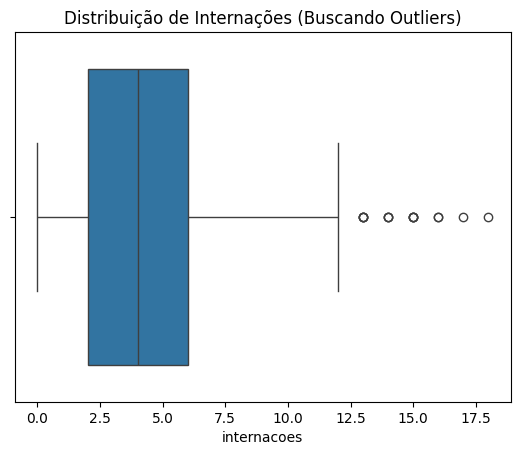

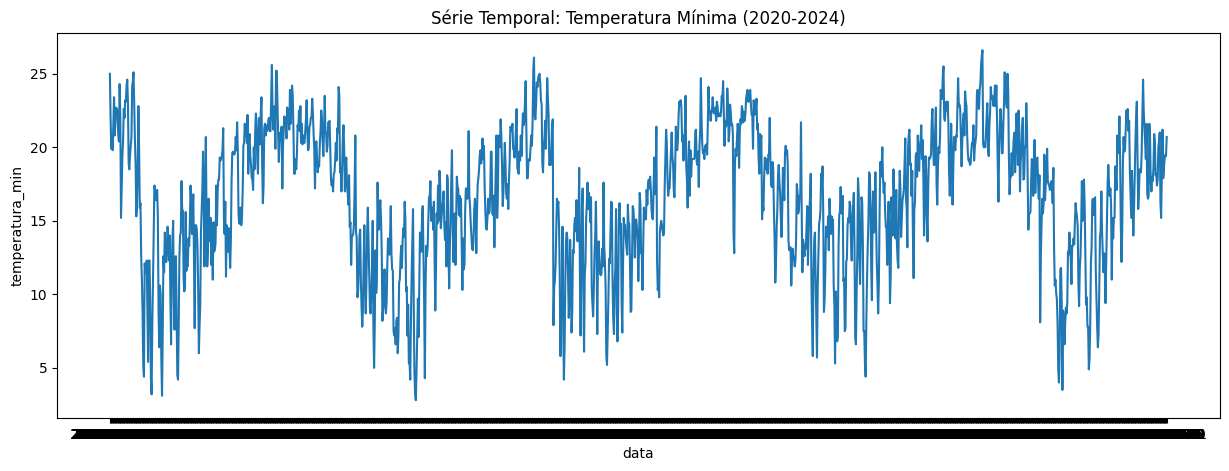

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot for a quick scan
sns.boxplot(x=df['internacoes'])
plt.title('Distribuição de Internações (Buscando Outliers)')
plt.show()

# Time-series plot to see seasonal spikes
plt.figure(figsize=(15, 5))
sns.lineplot(data=df, x='data', y='temperatura_min')
plt.title('Série Temporal: Temperatura Mínima (2020-2024)')
plt.show()

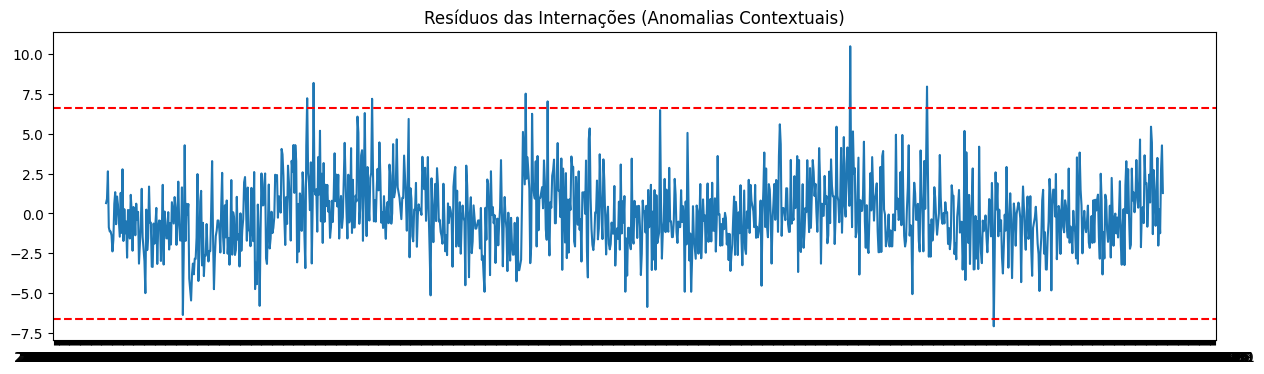

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# A base precisa estar com a data no index e ordenada
df_ts = df.set_index('data').sort_index()

# Decompor a série de internações
decomposicao = seasonal_decompose(df_ts['internacoes'], model='additive', period=365)

# Plotar os resíduos (o que sobra depois de tirar a tendência e a sazonalidade)
plt.figure(figsize=(15, 4))
plt.plot(decomposicao.resid)
plt.title('Resíduos das Internações (Anomalias Contextuais)')
plt.axhline(y=decomposicao.resid.std() * 3, color='r', linestyle='--') # Linha de alerta
plt.axhline(y=-decomposicao.resid.std() * 3, color='r', linestyle='--')
plt.show()

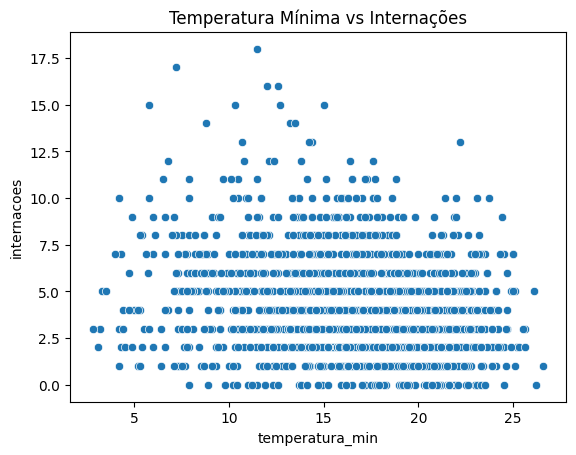

In [ ]:
import seaborn as sns

sns.scatterplot(data=df, x='temperatura_min', y='internacoes')
plt.title('Temperatura Mínima vs Internações')
plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

# Selecionar apenas as colunas numéricas (remova a data e os nulos por um momento)
features = ['temperatura_min', 'internacoes', 'umidade_rel', 'vento_velocidade']
df_limpo = df.dropna(subset=features).copy()

# Treinar o modelo para achar 2% de anomalias (contaminação)
modelo_iso = IsolationForest(contamination=0.02, random_state=42)
df_limpo['anomalia'] = modelo_iso.fit_predict(df_limpo[features])

# Filtrar os dias anômalos (-1 significa anomalia)
dias_estranhos = df_limpo[df_limpo['anomalia'] == -1]
print(dias_estranhos[['data', 'internacoes', 'temperatura_min']])

            data  internacoes  temperatura_min
46    2020-07-01            8             11.0
52    2020-07-07            0             11.5
59    2020-07-14            2              4.3
98    2020-08-22            1              4.2
112   2020-09-05            0             11.9
115   2020-09-08            6             14.8
231   2021-01-02            3             21.1
233   2021-01-04            3             25.6
372   2021-05-23            7             13.7
389   2021-06-09           12             16.4
402   2021-06-22           15             12.7
409   2021-06-29           17              7.2
428   2021-07-18            5              7.2
429   2021-07-19            5              9.3
432   2021-07-22           10              4.2
438   2021-07-28            6              4.7
439   2021-07-29            5              3.3
465   2021-08-24           13             14.4
544   2021-11-11           11             16.5
563   2021-11-30            9             20.8
641   2022-05

In [ ]:
# Fills gaps of up to 3 days using the temporal trend
df_hybrid = df.copy()
cols_poluicao = ['pm10', 'so2', 'no2', 'o3', 'co']
df_hybrid[cols_poluicao] = df_hybrid[cols_poluicao].interpolate(method='linear', limit=5)

In [ ]:
df_hybrid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1521 entries, 0 to 1520
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           1521 non-null   int64  
 1   data                 1521 non-null   object 
 2   precipitacao         1520 non-null   float64
 3   pressao_atm          1520 non-null   float64
 4   radiacao             1518 non-null   float64
 5   temperatura_ar       1520 non-null   float64
 6   temperatura_orvalho  1520 non-null   float64
 7   umidade_rel          1520 non-null   float64
 8   vento_direcao        1520 non-null   float64
 9   vento_rajada_max     1520 non-null   float64
 10  vento_velocidade     1520 non-null   float64
 11  temperatura_min      1520 non-null   float64
 12  temperatura_max      1520 non-null   float64
 13  pm10                 907 non-null    float64
 14  so2                  1519 non-null   float64
 15  no2                  1521 non-null   f

feature engeneering

In [ ]:
df_hybrid['data'] = pd.to_datetime(df_hybrid['data'], format='%Y-%m-%d')
# Criando features temporais essenciais
df_hybrid['mes'] = df_hybrid['data'].dt.month
df_hybrid['dia_semana'] = df_hybrid['data'].dt.dayofweek
df_hybrid['fim_de_semana'] = df_hybrid['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

# Opcional (mas recomendado): Estações do ano
df_hybrid['inverno'] = df_hybrid['mes'].apply(lambda x: 1 if x in [6, 7, 8] else 0)

# Certifique-se de que o dataframe está ordenado por data antes de fazer o shift!
df_hybrid = df_hybrid.sort_values('data')

criação da pipeline

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

# 1. Separar Variáveis Independentes (X) e a Variável Alvo (y)
# Tiramos a data e o ID porque modelos não leem isso
# Tiramos 'internacoes' de X porque ela é a resposta!

X = df_hybrid.drop(columns=['internacoes', 'data', 'Unnamed: 0',
                            'pm10_min', 'so2_min', 'no2_min', 'o3_min', 'co_min', 'pm10_max', 'so2_max', 'no2_max', 'o3_max', 'co_max', 'co'])
y = df_hybrid['internacoes']
datas = df_hybrid['data'] # Guardamos as datas para depois

# 2. O CORTE TEMPORAL (Garantindo que não há Data Leakage)
# Treino: 2020 até 2023 | Teste: 2024
limite_tempo = '2024-01-01'

X_train = X[datas < limite_tempo]
y_train = y[datas < limite_tempo]

X_test = X[datas >= limite_tempo]
y_test = y[datas >= limite_tempo]

# --- PIPELINE (Configurado igual fizemos antes) ---

# --- STEP 2: Triage the Features ---
# Group 1: Variables with predictable ranges (MinMax)
cols_minmax = [
    'temperatura_ar', 'temperatura_orvalho', 'temperatura_min',
    'temperatura_max', 'umidade_rel', 'vento_direcao'
]

# Group 2: Variables with massive spikes or heavy outliers (Robust)
# We use a list comprehension to easily grab all the pollutants and remaining columns
cols_robust = [col for col in X_train.columns if col not in cols_minmax]
print(cols_robust)

# --- STEP 3: Build the Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), cols_minmax),
        ('robust', RobustScaler(), cols_robust)
    ],
    remainder='drop' # Drops anything we forgot (though we caught everything)
)

['precipitacao', 'pressao_atm', 'radiacao', 'vento_rajada_max', 'vento_velocidade', 'pm10', 'so2', 'no2', 'o3', 'mes', 'dia_semana', 'fim_de_semana', 'inverno']


In [ ]:
from sklearn.preprocessing import FunctionTransformer

def gerador_de_lags(df):
    df_out = df.copy()

    # Adicionando o prefixo correto que o ColumnTransformer (preprocessor) aplica.
    # A temperatura_min está no grupo do MinMaxScaler. A poluição está no grupo RobustScaler.
    features_para_lag = [
        'minmax__temperatura_min',
        'minmax__umidade_rel',
        'robust__pm10'
    ]

    for col in features_para_lag:
        if col in df_out.columns:
            for dias in [1, 2, 3]:
                # Cria a coluna nova mantendo o prefixo
                df_out[f'{col}_lag{dias}'] = df_out[col].shift(dias)

    df_out = df_out.bfill()
    return df_out

cria_lags_transformer = FunctionTransformer(gerador_de_lags)

In [ ]:
from sklearn import set_config

# Força o Scikit-Learn inteiro a trabalhar apenas com Pandas DataFrames
set_config(transform_output="pandas")

In [ ]:
pipeline_completo = Pipeline([
    ('scaling', preprocessor),
    ('imputer', IterativeImputer(max_iter=30, random_state=42)),
    ('lags', cria_lags_transformer)])

fit = pipeline_completo.fit_transform(X_train)
print(fit.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1213 entries, 0 to 1212
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   minmax__temperatura_ar        1213 non-null   float64
 1   minmax__temperatura_orvalho   1213 non-null   float64
 2   minmax__temperatura_min       1213 non-null   float64
 3   minmax__temperatura_max       1213 non-null   float64
 4   minmax__umidade_rel           1213 non-null   float64
 5   minmax__vento_direcao         1213 non-null   float64
 6   robust__precipitacao          1213 non-null   float64
 7   robust__pressao_atm           1213 non-null   float64
 8   robust__radiacao              1213 non-null   float64
 9   robust__vento_rajada_max      1213 non-null   float64
 10  robust__vento_velocidade      1213 non-null   float64
 11  robust__pm10                  1213 non-null   float64
 12  robust__so2                   1213 non-null   float64
 13  robust__

spot checking inicial

In [ ]:
!pip install lightgbm

In [ ]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
import numpy as np

RANDOM_STATE = 42

models = {
    "LinearRegression": LinearRegression(),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
    "KNN": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "HistGB": HistGradientBoostingRegressor(loss='poisson', max_iter=200, random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
}

ts_cv = TimeSeriesSplit(n_splits=5)

results = {}
results_raw_mae = {}

print("\n===== SPOT-CHECKING (TIME SERIES RIGOROSO) =====")

for name, model in models.items():

    pipeline_completo = Pipeline([
    ('scaling', preprocessor),
    ('imputer', IterativeImputer(max_iter=30, random_state=RANDOM_STATE)),
    ('lags', cria_lags_transformer),
    ('model', model)
    ])

    scoring_metrics = {
        'MAE': 'neg_mean_absolute_error',
        "RMSE": "neg_root_mean_squared_error",
        'R2': 'r2'
    }

    # Rodando a Validação Cruzada Temporal
    scores = cross_validate(
        pipeline_completo,
        X_train, # Use o X_train ANTES da imputação
        y_train,
        cv=ts_cv,
        scoring=scoring_metrics,
        return_train_score=False,
        n_jobs=-1 # Usa todos os núcleos do seu PC para ir mais rápido
    )

    mae_scores = -scores['test_MAE']
    rmse_scores = -scores['test_RMSE']
    r2_scores = scores['test_R2']

    results_raw_mae[name] = mae_scores

    results[name] = {
        'MAE_mean': mae_scores.mean(),
        'MAE_std': mae_scores.std(),
        "RMSE_mean": rmse_scores.mean(),
        "RMSE_std": rmse_scores.std(),
        'R2_mean': r2_scores.mean(),
        'R2_std': r2_scores.std()
    }

    print(f"{name:18} | MAE: {mae_scores.mean():.4f} (±{mae_scores.std():.4f}) | R2: {r2_scores.mean():.4f} (±{r2_scores.std():.4f}) | RMSE: {rmse_scores.mean():.4f} (±{rmse_scores.std():.4f})")


===== SPOT-CHECKING (TIME SERIES RIGOROSO) =====
LinearRegression   | MAE: 2.3085 (±0.4559) | R2: -0.2170 (±0.3015) | RMSE: 2.9858 (±0.5264)
ElasticNet         | MAE: 2.2586 (±0.4246) | R2: -0.1759 (±0.2703) | RMSE: 2.9374 (±0.4809)
KNN                | MAE: 2.3285 (±0.3206) | R2: -0.2379 (±0.1896) | RMSE: 3.0231 (±0.4133)
DecisionTree       | MAE: 2.8455 (±0.2842) | R2: -0.8207 (±0.1594) | RMSE: 3.6588 (±0.3114)
RandomForest       | MAE: 2.3607 (±0.4448) | R2: -0.2769 (±0.2968) | RMSE: 3.0624 (±0.5333)
GradientBoosting   | MAE: 2.3842 (±0.4632) | R2: -0.3016 (±0.3054) | RMSE: 3.0887 (±0.5211)
HistGB             | MAE: 2.5562 (±0.6146) | R2: -0.5037 (±0.4315) | RMSE: 3.3128 (±0.6545)
LightGBM           | MAE: 2.4202 (±0.4977) | R2: -0.3217 (±0.3047) | RMSE: 3.1178 (±0.5452)


/tmp/ipykernel_3717/301555947.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_raw_mae[m] for m in results_raw_mae.keys()], labels=list(results_raw_mae.keys()), showmeans=True)


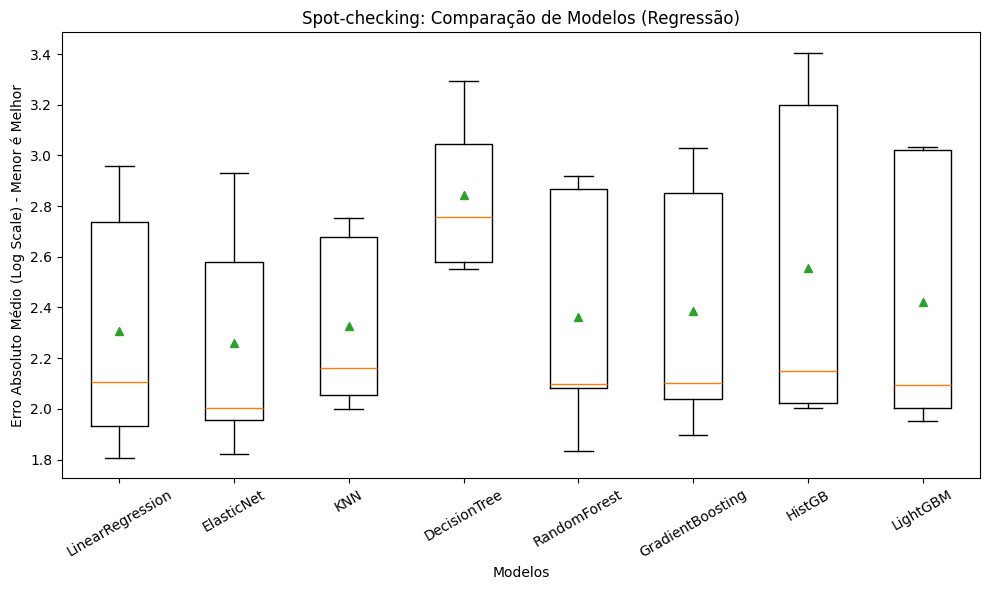

In [ ]:
# =========================================
# 4.1 Boxplot dos resultados
# =========================================
plt.figure(figsize=(10, 6))
plt.boxplot([results_raw_mae[m] for m in results_raw_mae.keys()], labels=list(results_raw_mae.keys()), showmeans=True)
plt.title("Spot-checking: Comparação de Modelos (Regressão)")
plt.xlabel("Modelos")
plt.ylabel("Erro Absoluto Médio (Log Scale) - Menor é Melhor")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()